In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
merged_df = pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/merged_cleaned.csv")

In [3]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 7043 non-null   object 
 1   gender                  7043 non-null   object 
 2   SeniorCitizen           7043 non-null   int64  
 3   Partner                 7043 non-null   object 
 4   Dependents              7043 non-null   object 
 5   months_active           7043 non-null   int64  
 6   PhoneService            7043 non-null   object 
 7   MultipleLines           7043 non-null   object 
 8   InternetService         7043 non-null   object 
 9   OnlineSecurity          7043 non-null   object 
 10  OnlineBackup            7043 non-null   object 
 11  DeviceProtection        7043 non-null   object 
 12  TechSupport             7043 non-null   object 
 13  StreamingTV             7043 non-null   object 
 14  StreamingMovies         7043 non-null   

We define our target variable as churn_label. We remove columns that are not predictive features, like user IDs, experiment info, and funnel stage indicators.

In [4]:
y = merged_df['churn_label']

In [5]:
drop_cols = [
    'user_id',
    'churn_label',
    'experiment_group',
    'experiment_start_month',
    'stage_signup',
    'stage_active',
    'stage_engaged',
    'stage_retained'
]

In [6]:
X = merged_df.drop(columns=drop_cols)

In [7]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 34)
Target shape: (7043,)


In [8]:
X = pd.get_dummies(X, drop_first=True)

print("New feature shape after encoding:", X.shape)

New feature shape after encoding: (7043, 52)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 52)
Test size: (1409, 52)


In [10]:
print("Churn Distribution:")
print(y.value_counts(normalize=True))

Churn Distribution:
churn_label
0    0.73463
1    0.26537
Name: proportion, dtype: float64


We standardize numeric features to bring them onto the same scale, which helps some models perform better.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [13]:
print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("\n", classification_report(y_test, y_pred_log))

LOGISTIC REGRESSION
Accuracy: 0.8034066713981547
Precision: 0.656957928802589
Recall: 0.5427807486631016
ROC-AUC: 0.8423854917461056

               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [14]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [15]:
print("DECISION TREE")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

DECISION TREE
Accuracy: 0.7814052519517388
Precision: 0.6050955414012739
Recall: 0.5080213903743316
ROC-AUC: 0.81133069828722


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [17]:
print("RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RANDOM FOREST
Accuracy: 0.8055358410220014
Precision: 0.6785714285714286
Recall: 0.5080213903743316
ROC-AUC: 0.8415717275052313


In [18]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:45:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
print("XGBOOST")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBOOST
Accuracy: 0.7913413768630234
Precision: 0.6324503311258278
Recall: 0.5106951871657754
ROC-AUC: 0.8280709912423467


We evaluate each model using accuracy, precision, recall, and ROC-AUC to see which performs best for predicting churn.

In [20]:
results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results.sort_values("ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic,0.803407,0.656958,0.542781,0.842385
2,Random Forest,0.805536,0.678571,0.508021,0.841572
3,XGBoost,0.791341,0.632450,0.510695,0.828071
1,Decision Tree,0.781405,0.605096,0.508021,0.811331


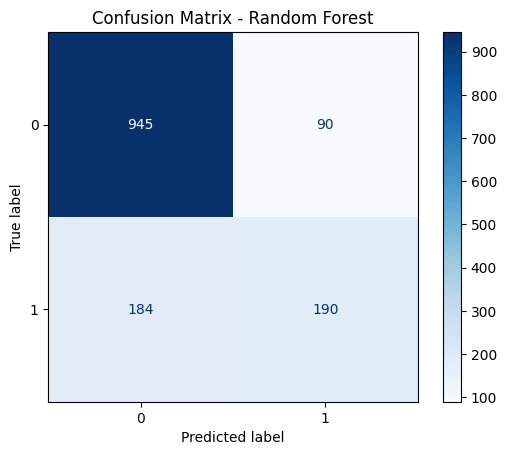

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

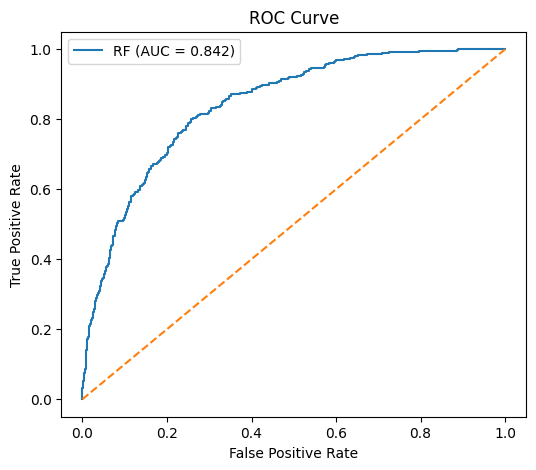

In [22]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"RF (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Catching churners early is more valuable than avoiding false alarms

In [23]:
threshold = 0.35
y_pred_custom = (y_prob_rf >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))

Precision: 0.5572033898305084
Recall: 0.7032085561497327


After lowering the threshold to 0.35, our model now identifies 70% of actual churners correctly, which is a big improvement in Recall. However, Precision dropped to 56%, meaning some users flagged as churners won’t actually churn. This is a tradeoff between catching more churners and avoiding false positives. For a streaming service, catching more potential churners is usually more valuable, as we can take action early to retain them.

In [24]:
merged_df['churn_probability'] = rf_model.predict_proba(X)[:,1]

merged_df[['user_id','churn_probability']].head()

,user_id,churn_probability
0,7590-VHVEG,0.531858
1,5575-GNVDE,0.043010
2,3668-QPYBK,0.603431
3,7795-CFOCW,0.046739
4,9237-HQITU,0.645119


In [26]:
import joblib

# Save trained models
joblib.dump(rf_model, "RandomForest_churn_model.pkl")
joblib.dump(xgb_model, "XGBoost_churn_model.pkl")
joblib.dump(log_model, "Logistic_churn_model.pkl")
joblib.dump(dt_model, "DecisionTree_churn_model.pkl")

# Save scaler too (needed for Logistic Regression)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [27]:
import pickle
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)